<a href="https://colab.research.google.com/github/NathalieKa/Python101/blob/main/MatrixMultiply.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<figure>
  <IMG SRC="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Fachhochschule_Südwestfalen_20xx_logo.svg/320px-Fachhochschule_Südwestfalen_20xx_logo.svg.png" WIDTH=250 ALIGN="right">
</figure>

# Einführung Machine Learning
### Sommersemester 2026
Prof. Dr. Heiner Giefers

## Aufgabe: Matrizenmultiplikation in Python

Wir importieren NumPy und erzeugen zwei Matrizen der Größe $N\times{}N$ mit gleichverteilten Zufallszahlen aus dem Bereich $[0,1)$.

In [1]:
import numpy as np

N = 100
A = np.random.rand(N, N) #100X100
B = np.random.rand(N, N)

Wir wollen nun die beiden NumPy Matrizen miteinander multiplizieren. Dazu können wir den Matrizenmultiplikations-Operator `@` von NumPy verwenden.

Um die Laufzeit dieser Operation zu messen, verwenden wir eine sogenannte *IPython Magic Function* namens `timeit`.
*Magic Functions* werden mit einem vorangestellten `%` aufgerufen:

In [2]:
%timeit C=A@B

83.9 µs ± 26.7 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


**timeit** = Er misst, wie lange der Code dahinter zur Ausführung braucht. Dabei führt er den Code nicht nur einmal aus, sondern viele Male hintereinander, und berechnet daraus einen zuverlässigen Durchschnitt.

Die Multiplikation dauerte im Schnitt 52,3 Mikrosekunden pro Durchlauf, mit einer Standardabweichung von 1,2 µs, basierend auf 7 Runden à 10.000 Wiederholungen.

Nun wollen wir die gleiche Operation in Python, also ohne NumPy implementieren.
Dazu wandeln wir zunächst die *ndarrays* `A` und `B` in *normale* Python Listen-Objekte um:

In [3]:
A_list = A.tolist() #Array in Liste konvertieren
B_list = B.tolist()
type(A_list), type(B_list)

(list, list)

Nun sind Sie an der Reihe. Schreiben Sie eine Funktion `matmul` mit der Sie eine Matrizenmultiplikation zweier Matrizen `A` und `B` durchführen. Gehen Sie davon aus, dass `A` und `B` als zweidimensionale Listen (*Listen von Listen*) übergeben werden. Die Funktion soll eine neue Matrix `C` zurückliefern.

![](https://github.com/fh-swf-hgi/intro-ml/raw/main/Praktika/A03/matmult.png)

In [4]:
def matmul(A,B):
    C = []
    for i in range(len(A)):
      zeile = []
      for j in range(len(B[0])):
        summe = 0
        for k in range(len(A[0])):
           summe = summe + (A[i][k] * B[k][j])
        zeile.append(summe)
      C.append(zeile)

    return C



    #raise NotImplementedError()

In [5]:
A_ = [[1,2,3,4],[5,6,7,8],[9,10,11,12]]
B_ = [[1,2,3],[4,5,6],[7,8,9],[10,11,12]]
assert matmul(A_,B_) == [[70, 80, 90], [158, 184, 210], [246, 288, 330]]

Testen Sie nun die Laufzeit der selbst implementierten Matrizenmultiplikation.

In [6]:
%timeit C=matmul(A_list,B_list)
#raise NotImplementedError()

54 ms ± 968 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [7]:
assert 'timeit' in _i

Wiederholen Sie die Messungen für verschiedene Größen von N.
Sammeln Sie die Luafzeitergebnisse in zwei Listen `run_numpy` und `run_py`.

Um ein Ergebnis von der `timeit` Funktion zu bekommen, rufen Sie die Funktion folgendermaßen auf:

In [8]:
t = %timeit -o C=A@B
print(f"Mittlere Laufzeit = {t.average}s")

48.3 µs ± 1.14 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
Mittlere Laufzeit = 4.8343846157139786e-05s


In [9]:

run_numpy = []
run_py = []

N_values = [10, 20, 30, 40, 50, 100]


for i in N_values:
  A = np.random.rand(i,i)
  B = np.random.rand(i,i)
  t1 = %timeit -o C=A@B
  run_numpy.append(t1.average)

  t2 = %timeit -o C = matmul(A,B)
  run_py.append(t2.average)


print("run numpy")
for wert in run_numpy:
  print(wert)

print("run py")
for wert in run_py:
  print(wert)



#raise NotImplementedError()

2.12 µs ± 557 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)
581 µs ± 5.69 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
2.39 µs ± 66.3 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)
4.65 ms ± 98.3 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
5.11 µs ± 1.21 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)
16.9 ms ± 3.9 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
4.63 µs ± 326 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)
36.2 ms ± 634 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
8.66 µs ± 2.05 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)
71.2 ms ± 2.14 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
60.7 µs ± 9.38 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
560 ms ± 8.06 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
run numpy
2.1204302528571555e-06
2.389506165714173e-06
5.107437407142957e-06
4.6329844699999154e-06
8.65665712571464e-06
6.06513

In [10]:
assert len(run_numpy)>0
assert len(run_numpy)==len(run_py)

Verwenden Sie *Matplotlib*, um beiden Messreihen in einen Graphen zu plotten.

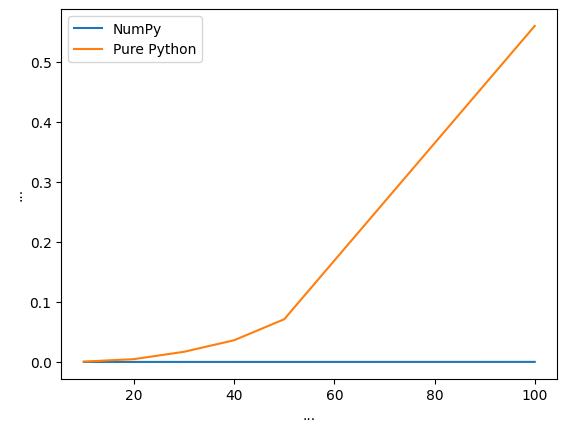

In [13]:
import matplotlib.pyplot as plt

plt.plot(N_values, run_numpy, label="NumPy")
plt.plot(N_values, run_py,    label="Pure Python")

plt.xlabel("...")     # was steht auf der x-Achse?
plt.ylabel("...")     # was steht auf der y-Achse?
plt.legend()
plt.show()
#raise NotImplementedError()

In [14]:
assert 'plt.' in _i